# Análise de Passagens e Melhores Janelas

**OrbitHam · Global Solution FIAP**

Para operar uma estação terrena importa saber *quando* os satélites passam, *por quanto tempo* e *com que qualidade* (elevação máxima). Aqui geramos todas as passagens sobre uma estação ao longo de 14 dias e descobrimos os melhores horários para operar.

> ### Resumo para o vídeo
> **O que faz:** encontra as melhores janelas para operar a estação, analisando as passagens dos satélites.
>
> **Stack:** Python · Skyfield · Pandas · Seaborn · scikit-learn.
>
> **Dados:** 182 passagens em 14 dias sobre São Paulo (4 satélites).
>
> **Melhores horários:** por volta das **11h e 22h** (hora local).
>
> **ML:** classificador de qualidade da passagem com **~84% de acurácia**; passagens mais longas têm elevação maior.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import orbitham_analytics as oa

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4.5)
START = datetime(2024, 10, 25, tzinfo=timezone.utc)

# Estação: São Paulo (capital, Sudeste).
LAT, LON, ALT = -23.5505, -46.6333, 760

## 1. Gerando o conjunto de passagens

In [2]:
tles = oa.load_sample()
df = oa.build_pass_dataset(tles, LAT, LON, altitude_m=ALT, days=14, start=START)
print(f'{len(df)} passagens em 14 dias, {df.satellite.nunique()} satélites')
df[['satellite', 'rise', 'max_elevation', 'duration_min', 'hour', 'quality']].head()

182 passagens em 14 dias, 4 satélites


,satellite,rise,max_elevation,duration_min,hour,quality
0,AO-7 (OSCAR 7),2024-10-25 01:16:32.466997+00:00,63.0,16.467483,22,Excelente
1,FOX-1A (AO-85),2024-10-25 02:40:11.960673+00:00,13.9,4.743331,23,Ruim
2,AO-7 (OSCAR 7),2024-10-25 03:11:57.379587+00:00,20.0,11.398423,0,Ruim
3,FOX-1A (AO-85),2024-10-25 04:18:17.551280+00:00,40.5,8.784491,1,Média
4,ISS (ZARYA),2024-10-25 06:40:32.968994+00:00,87.7,6.726088,3,Excelente


## 2. Distribuições

Como se distribuem a elevação máxima e a duração das passagens?

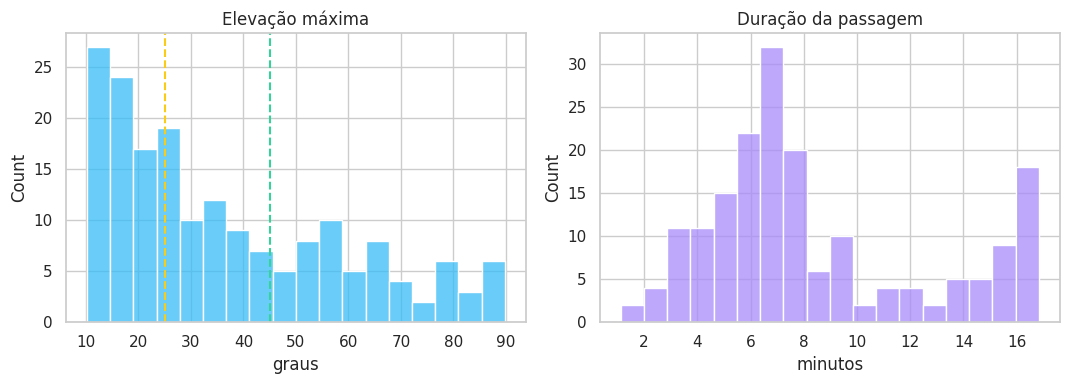

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['max_elevation'], bins=18, ax=axes[0], color='#38bdf8')
axes[0].axvline(45, color='#34d399', ls='--'); axes[0].axvline(25, color='#facc15', ls='--')
axes[0].set_title('Elevação máxima'); axes[0].set_xlabel('graus')
sns.histplot(df['duration_min'], bins=18, ax=axes[1], color='#a78bfa')
axes[1].set_title('Duração da passagem'); axes[1].set_xlabel('minutos')
plt.tight_layout(); plt.show()

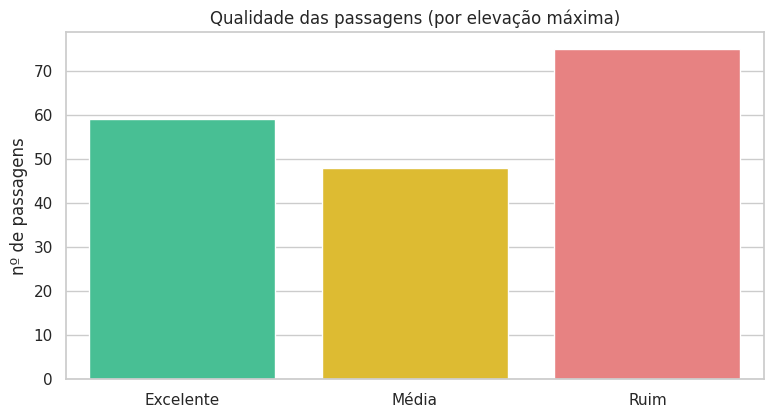

In [4]:
ordem = ['Excelente', 'Média', 'Ruim']
cores = {'Excelente': '#34d399', 'Média': '#facc15', 'Ruim': '#f87171'}
cont = df['quality'].value_counts().reindex(ordem)
ax = sns.barplot(x=ordem, y=cont.values, hue=ordem,
                 palette=cores, legend=False)
ax.set_title('Qualidade das passagens (por elevação máxima)')
ax.set_ylabel('nº de passagens')
plt.show()

## 3. Melhores janelas (por horário)

Quando, no dia, há mais passagens e de melhor qualidade? (hora local, UTC-3)

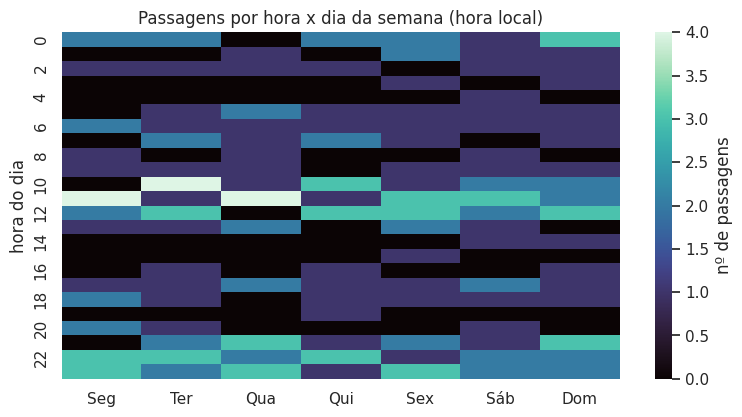

In [5]:
dias = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
pivot = df.pivot_table(index='hour', columns='weekday',
                       values='max_elevation', aggfunc='count', fill_value=0)
pivot = pivot.reindex(columns=range(7), fill_value=0)
ax = sns.heatmap(pivot, cmap='mako', cbar_kws={'label': 'nº de passagens'})
ax.set_xticklabels(dias)
ax.set_title('Passagens por hora x dia da semana (hora local)')
ax.set_xlabel(''); ax.set_ylabel('hora do dia')
plt.show()

Melhores janelas (hora local):
  11h  ->  18 passagens, elevação média 49°
  22h  ->  16 passagens, elevação média 54°
  23h  ->  16 passagens, elevação média 39°
  12h  ->  16 passagens, elevação média 33°
  10h  ->  13 passagens, elevação média 37°


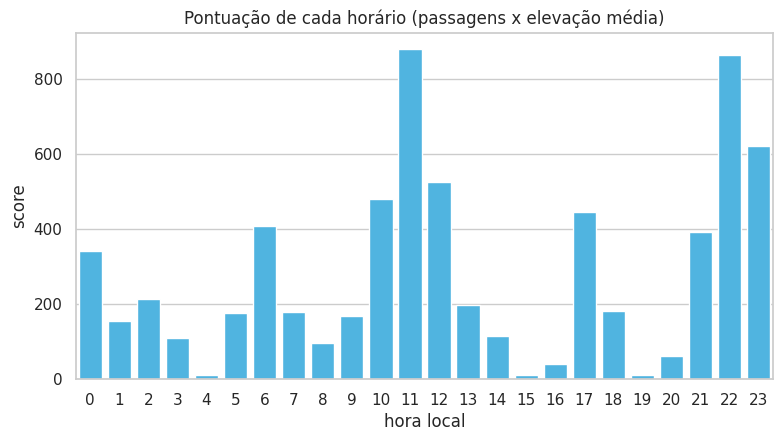

In [6]:
por_hora = df.groupby('hour').agg(
    passagens=('max_elevation', 'count'),
    elev_media=('max_elevation', 'mean'),
).reset_index()
por_hora['score'] = por_hora['passagens'] * por_hora['elev_media']
melhores = por_hora.sort_values('score', ascending=False).head(5)
print('Melhores janelas (hora local):')
for _, r in melhores.iterrows():
    print(f'  {int(r.hour):02d}h  ->  {int(r.passagens)} passagens, '
          f'elevação média {r.elev_media:.0f}°')

ax = sns.barplot(data=por_hora, x='hour', y='score', color='#38bdf8')
ax.set_title('Pontuação de cada horário (passagens x elevação média)')
ax.set_xlabel('hora local'); ax.set_ylabel('score')
plt.show()

## 4. Melhores satélites

In [7]:
por_sat = df.groupby('satellite').agg(
    passagens=('max_elevation', 'count'),
    elev_media=('max_elevation', 'mean'),
    elev_max=('max_elevation', 'max'),
    dur_media=('duration_min', 'mean'),
).round(1).sort_values('elev_media', ascending=False)
por_sat

,passagens,elev_media,elev_max,dur_media
satellite,,,,
AO-7 (OSCAR 7),59,40.2,89.8,13.5
ISS (ZARYA),42,35.5,87.7,5.5
FOX-1A (AO-85),43,35.3,88.2,6.7
FOX-1D (AO-92),38,34.4,83.2,5.8


## 5. Machine Learning introdutório

Duas perguntas:
1. **Regressão:** passagens mais longas tendem a ter elevação mais alta?
2. **Classificação:** dá para prever a *qualidade* de uma passagem a partir de características dela?

max_elevation ~ 2.62 * duracao + 14.6
R2 = 0.25


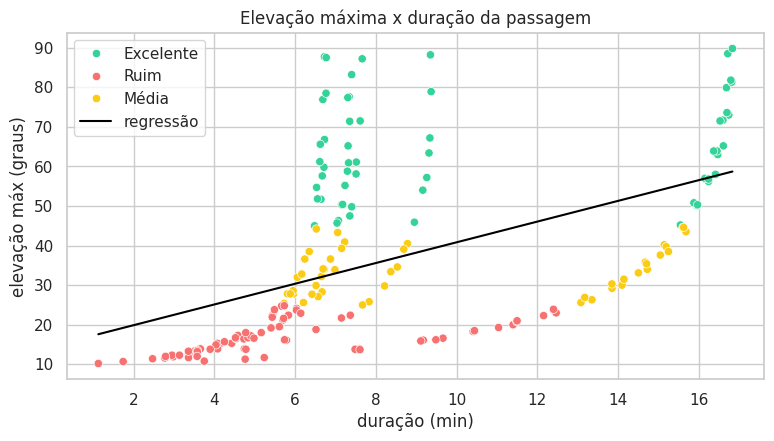

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['duration_min']].to_numpy()
y = df['max_elevation'].to_numpy()
reg = LinearRegression().fit(X, y)
pred = reg.predict(X)
print(f'max_elevation ~ {reg.coef_[0]:.2f} * duracao + {reg.intercept_:.1f}')
print(f'R2 = {r2_score(y, pred):.2f}')

ax = sns.scatterplot(data=df, x='duration_min', y='max_elevation', hue='quality',
                     palette={'Excelente': '#34d399', 'Média': '#facc15', 'Ruim': '#f87171'})
xs = np.linspace(df.duration_min.min(), df.duration_min.max(), 100)
ax.plot(xs, reg.predict(xs.reshape(-1, 1)), color='black', lw=1.5, label='regressão')
ax.set_title('Elevação máxima x duração da passagem')
ax.set_xlabel('duração (min)'); ax.set_ylabel('elevação máx (graus)')
plt.legend(); plt.show()

Acurácia: 0.84
              precision    recall  f1-score   support

   Excelente       0.77      0.94      0.85        18
       Média       0.75      0.64      0.69        14
        Ruim       0.95      0.87      0.91        23

    accuracy                           0.84        55
   macro avg       0.83      0.82      0.82        55
weighted avg       0.84      0.84      0.83        55



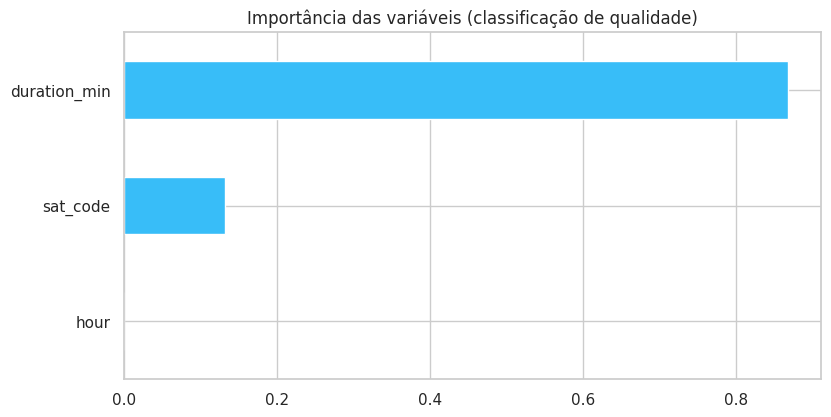

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

feat = df.copy()
feat['sat_code'] = feat['satellite'].astype('category').cat.codes
X = feat[['duration_min', 'hour', 'sat_code']]
y = feat['quality']
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
clf = DecisionTreeClassifier(max_depth=4, random_state=42).fit(Xtr, ytr)
pred = clf.predict(Xte)
print(f'Acurácia: {accuracy_score(yte, pred):.2f}')
print(classification_report(yte, pred))

imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
ax = imp.plot(kind='barh', color='#38bdf8')
ax.set_title('Importância das variáveis (classificação de qualidade)')
plt.show()

## Conclusões

- As **melhores janelas** sobre a estação se concentram em certos horários (ver heatmap e pontuação), o que permite planejar a operação.
- Há uma relação clara e fisicamente esperada: **passagens mais longas tendem a ter elevação máxima maior**, pois passagens próximas do zênite cruzam mais céu.
- O classificador prevê a **qualidade** da passagem com boa acurácia usando duração, horário e satélite; a **duração** é a variável mais informativa.
- Tudo reaproveita o mesmo motor (Skyfield) e os mesmos limiares de qualidade (45°/25°) do app OrbitHam, mantendo análise e produto coerentes.